In [1]:
import numpy as np 
import pandas as pd 
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, Normalizer, RobustScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, LassoCV, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import minimize



pd.set_option('display.max_columns', None)

pd.set_option('display.max_rows', None)

# Ignorer tous les avertissements (utilisez avec précaution)
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('Data_Modelisation-3.csv')
df = df[~(df["Contaminant"].isin(["DRY"]))]
df = df.drop(['Moyenne CFL F',"hauteur (mm)",'Fv (kg)','Tsurf (C)'], axis=1)


df = df[df.Vitesse == 65]

df = df.drop(["Vitesse"],axis = 1)


# df.Vitesse = df.Vitesse.astype(str)

In [3]:
df.shape

(551, 5)

## Adding some data

on va ajouter 3 points sur trois positions: 60, 80 et 90. Sachant que les valeurs de CFL prennent des valeurs proches de la valeur du CFL pour la valeur maximale de glissement, en prenant compte qu'elles doivent être tres proches mais supperieurs, on va ajouter: pour 90 on ajoute la valuer medianne des CFL du glissement consigne 100 + 0.0025, pour 80 on ajoute la valuer medianne des CFL du glissement consigne 100 + 0.005, pour 60 on ajoute la valuer medianne des CFL du glissement consigne 100 + 0.01.

In [4]:
c = []
g = []
cfl = []
t = []
for i in df.Contaminant.unique():
    y1 = df[(df.Contaminant == i) & (df.Glissement == 100)]["Moyenne CFL C"].median()
    y2 = df[(df.Contaminant == i) & ((df.Glissement < 15) | (df.Glissement > 11))]["Moyenne CFL C"].median()
    a = (y1-y2)/(100-13)
    b = y1 - a*100
    temp = df[(df.Contaminant == i) & (df.Glissement == 100)]['T° BDR (C)'].median()
    for k in [30,40,60,80,90]:
        c+= [i]
        g+= [k]
        cfl+= [a * k + b]
        t+=[temp]


more_data = pd.DataFrame({
              "Glissement" : g,
             "Moyenne CFL C" : cfl,
             'Moyenne G% [%]' : g,
              'T° BDR (C)' : t,
              "Contaminant" : c
             })

In [5]:
# Avec la vitesse
# c = []
# v = []
# g = []
# cfl = []
# t = []
# for i in df.Contaminant.unique():
#     for j in df.Vitesse.unique():
#         y1 = df[(df.Contaminant == i) & (df.Vitesse == j) & (df.Glissement == 100)]["Moyenne CFL C"].median()
#         y2 = df[(df.Contaminant == i) & (df.Vitesse == j) & ((df.Glissement < 16) | (df.Glissement > 11))]["Moyenne CFL C"].median()
#         a = (y1-y2)/(100-13.5)
#         b = y1 - a*100
#         temp = df[(df.Contaminant == i) & (df.Vitesse == j) & (df.Glissement == 100)]['T° BDR (C)'].median()
#         for k in [30,40,60,80,90]:
#             c+= [i]
#             v+= [j]
#             g+= [k]
#             cfl+= [a * k + b]
#             t+=[temp]


# more_data = pd.DataFrame({"Vitesse" : v,
#               "Glissement" : g,
#              "Moyenne CFL C" : cfl,
#              'Moyenne G% [%]' : g,
#               'T° BDR (C)' : t,
#               "Contaminant" : c
#              })

In [6]:
df = pd.concat([df, more_data], axis = 0)

In [7]:
X_o = df.drop('Glissement',axis = 1).copy()
#X_o["descritisation"] = X_o['Moyenne G% [%]'].apply(descritisation)
#y = df['Moyenne CFL C']

### Analyse par chaque contaminant:

In [8]:
# Neige fraiche (B)
nfb = X_o[X_o.Contaminant == 'Neige fraiche (B)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Neige fraiche (G)
nfg = X_o[X_o.Contaminant == 'Neige fraiche (G)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# N.C. (G)
ncg = X_o[X_o.Contaminant == 'N.C. (G)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# N.C. (B)
ncb = X_o[X_o.Contaminant == 'N.C. (B)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# NC.C.
ncc = X_o[X_o.Contaminant == 'NC.C.'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Verglas
ver = X_o[X_o.Contaminant == 'Verglas'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Glace
gla = X_o[X_o.Contaminant == 'Glace'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# SLUSH
slh = X_o[X_o.Contaminant == 'SLUSH'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Columns to drop in every modele


In [9]:
l=[nfb, nfg, ncg, ncb, ncc, ver,  gla, slh]
names = ['nfb', 'nfg', 'ncg', 'ncb', 'ncc', 'ver',  'gla', 'slh']
Contaminant = ['Neige fraiche (B)', 'Neige fraiche (G)', 'N.C. (G)', 'N.C. (B)', 'NC.C.', 'Verglas', 'Glace', 'SLUSH']
dict = {"Contaminant" : Contaminant, "Nombre d'observation" : list(map(lambda x: x.shape[0], l))}
pd.DataFrame(dict).sort_values(["Nombre d'observation"], ascending = False).reset_index(drop = True)

,Contaminant,Nombre d'observation
0,Neige fraiche (B),133
1,NC.C.,112
2,Neige fraiche (G),93
3,N.C. (B),80
4,N.C. (G),59
5,Glace,54
6,Verglas,33
7,SLUSH,27


## Data Preprocessing

In [10]:
def scale_encode(x,y = 0):
    encoder = OneHotEncoder(drop='first')
    # Séparer les variables qualitatives et numériques
    qualitative_vars = ['Vitesse']
    numeric_vars = x.select_dtypes(include=['float']).columns.tolist()
    
    # Appliquer le one-hot encoding aux variables qualitatives
    encoded_vars = encoder.fit_transform(x[qualitative_vars]).toarray()
    encoded_columns = encoder.get_feature_names_out(qualitative_vars)
    encoded_df = pd.DataFrame(encoded_vars, columns=encoded_columns)
    if y == 1:  # Appliquer le StandardScaler aux variables numériques
        scaler = StandardScaler().set_output(transform='pandas')
    elif y == 2:  # Appliquer le Normalizer aux variables numériques
        scaler = Normalizer().set_output(transform='pandas')
    else:
        X = pd.concat([x.drop(['Vitesse'], axis=1), encoded_df], axis=1)
        return X
    
    # Appliquer le scaler et transformer les variables numériques
    scaled_df = scaler.fit_transform(x[numeric_vars])
    
    # Concaténation des DataFrames encodé et standardisé
    X = pd.concat([scaled_df, encoded_df], axis=1)
    return X
#Fonction utile
def coef(i=0):
    y_pred = regressor.predict(X_test)
    y_pred_train = regressor.predict(X_train)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = (y_test-y_pred).abs().mean()
    
    mse_train = mean_squared_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)
    mae_train = (y_train-y_pred_train).abs().mean()
    
    
    if i==1:
        print(f"Pour le test: RMSE = {round((np.sqrt(mse)),5)}, R² = {round(r2*100,2)}, MAE = {round(mae,5)}")
        print(f"Pour le train: RMSE = {round((np.sqrt(mse_train)),5)}, R² = {round(r2_train*100,2)}, MAE = {round(mae_train,5)}")
    coefficients = np.concatenate([[regressor.intercept_],regressor.coef_])
    features = ["Intercept"] + X.columns.to_list()
    
    coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coefficients})
    coef_df['Coefficient'] = coef_df['Coefficient'].apply(lambda x: f"{x:.6f}")
    
    return coef_df


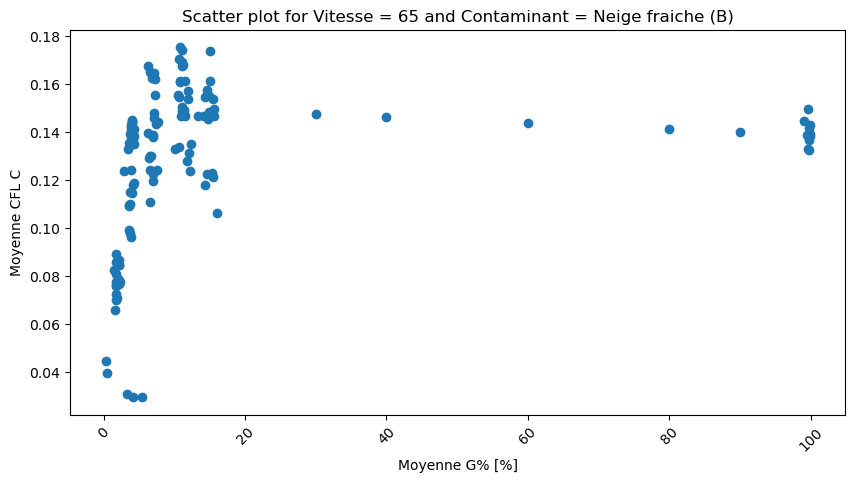

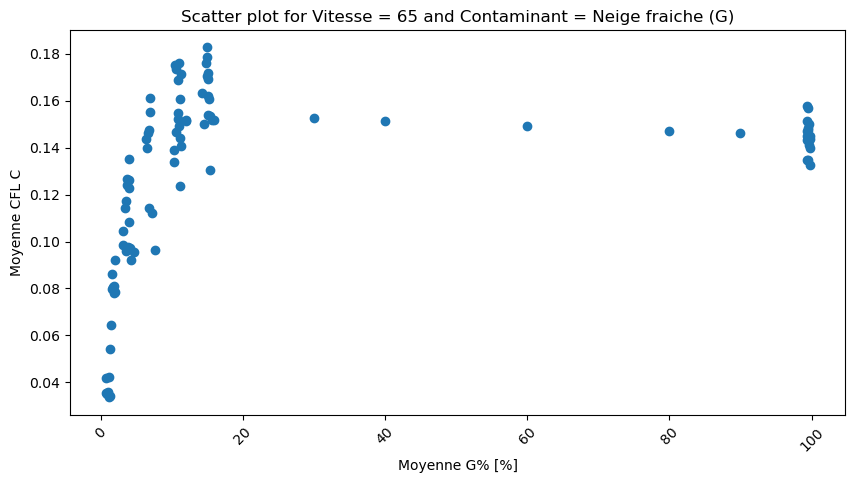

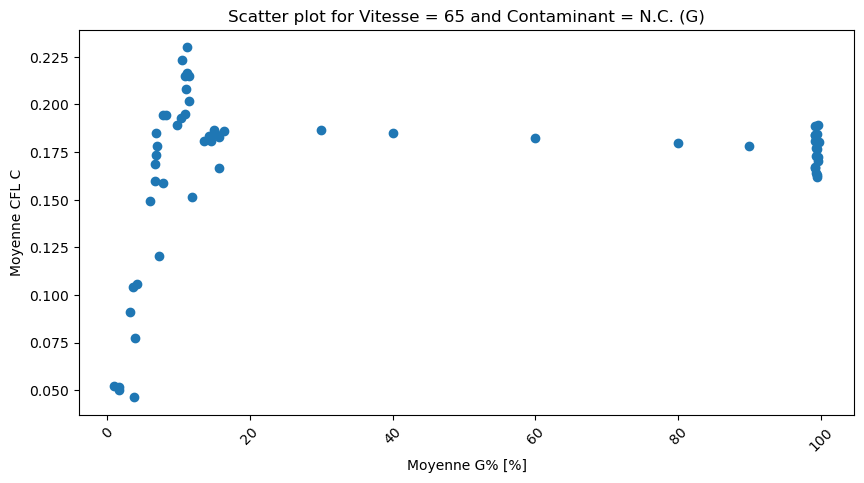

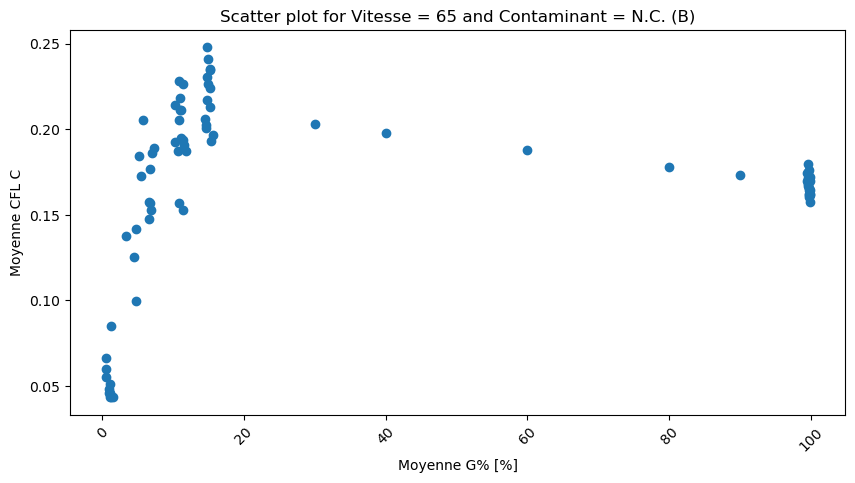

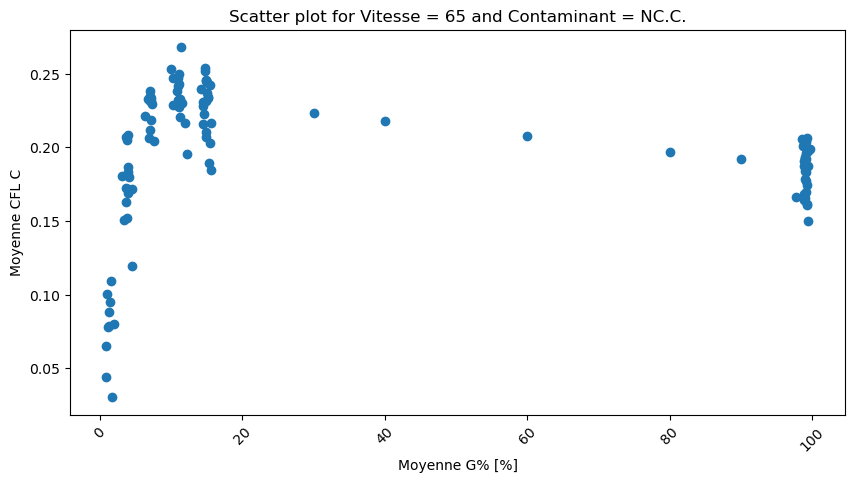

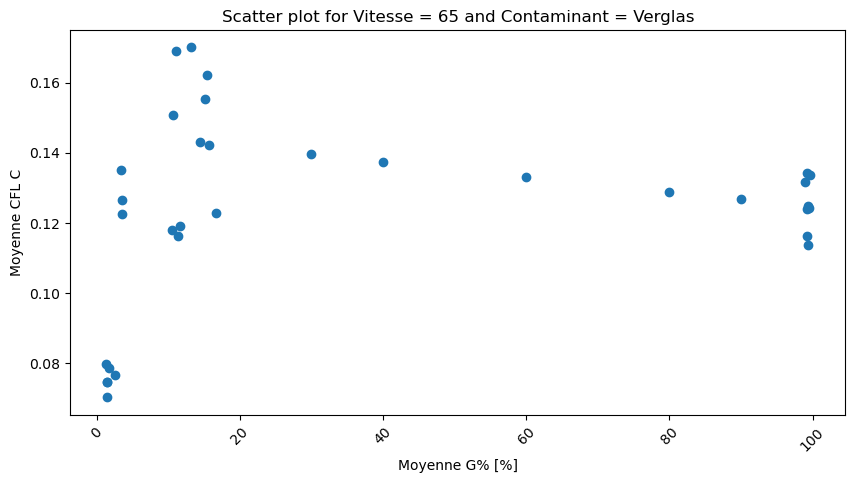

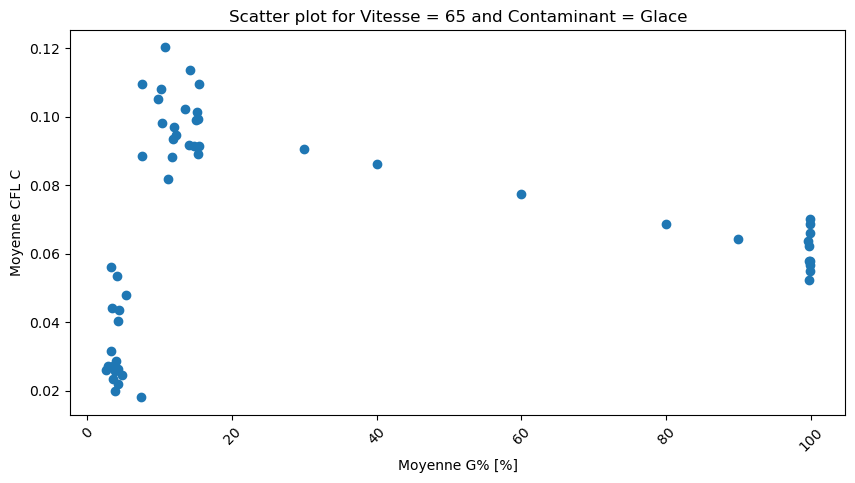

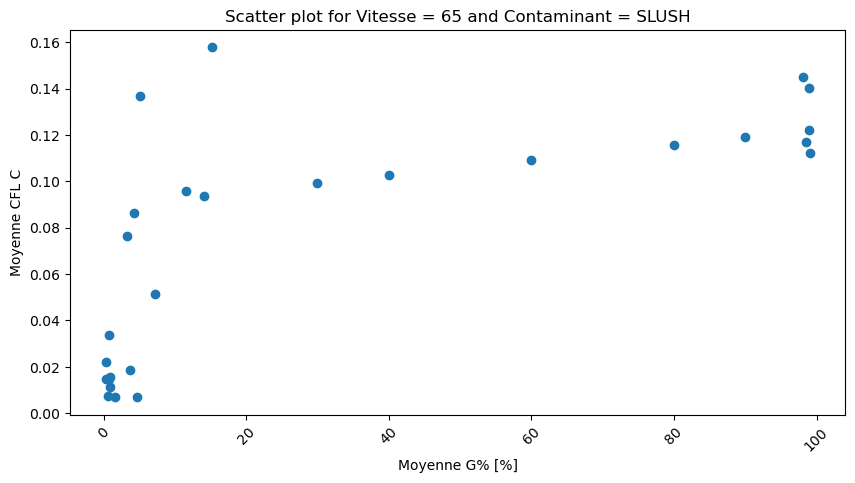

In [11]:
a=1

for i in df.Contaminant.unique():    
    plt.figure(figsize=(10, 5))
    v = "65"
    c = i
    x_data = df[ (df.Contaminant == i)]["Moyenne G% [%]"]
    y_data = df[(df.Contaminant == c)]["Moyenne CFL C"]
    plt.scatter(x_data, y_data)
    plt.xlabel("Moyenne G% [%]")
    plt.ylabel("Moyenne CFL C")
    plt.title(f"Scatter plot for Vitesse = {v} and Contaminant = {c}")
    
    # Optionnel: définir les graduations de l'axe des x
    plt.xticks(rotation=45)  # Exemple : rotation des graduations pour une meilleure lisibilité
    plt.show()

## Neige fraiche (B) (173 observations)

In [12]:
def descritisation_nfb(x):
    if x< 6:
        return "8"
    elif x< 11:
        return "11"
    elif x< 14:
        return "14"
    elif x< 16:
        return "16"
    else:
        return "more"

data = nfb 
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
X["rg"] = np.sqrt(X['Moyenne G% [%]'])
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

In [13]:
X['Moyenne G% [%]'][np.argmax(y)]

10.732380952380954

In [14]:
np.argmax(y)

113

In [15]:
nfb

,Moyenne CFL C,Moyenne G% [%],T° BDR (C)
0,0.044667,0.260000,2.330940
1,0.039714,0.409524,2.329125
2,0.029429,4.120000,2.140940
3,0.029524,5.380476,2.213052
4,0.030857,3.300952,2.174634
5,0.109619,3.515238,3.394108
6,0.114524,3.954286,3.416081
7,0.115143,3.668571,3.391421
8,0.110095,3.681429,3.373470
9,0.118762,4.274762,3.398381


In [157]:
float(nfb[nfb['Moyenne G% [%]'] == 60]['Moyenne CFL C'])

0.1438204707170224

### Attempt 1

In [16]:
from scipy.optimize import minimize, differential_evolution

def objective(params, X, y):
    a, b, c, d = params
    y_pred = a + b * X['Moyenne G% [%]'] + c * X["g2"] + d * X["rg"]
    f = lambda x: a + b * x + c * x**2 + d * np.sqrt(x)
    
    # Utiliser x pour calculer la fonction de régression complète
    x = np.linspace(0, 100, 1000)
    y_reg = f(x)
    # v_30 = float(nfb[nfb['Moyenne G% [%]'] == 30]['Moyenne CFL C'])
    
    
    # Trouver les valeurs de g où les maxima sont atteints
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]

    # Calculer les différences de valeurs et d'abscisses
    max_abscissa_diff = (g_max_real - g_max_pred)**2
    
    # Combiner les objectifs
    mse = mean_squared_error(y, y_pred)
    cost = mse  + max_abscissa_diff#+ (f(30) - v_40)**2

    print(g_max_pred)
    return cost

data = nfb 
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
X["rg"] = np.sqrt(X['Moyenne G% [%]'])
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

st = X['Moyenne G% [%]'].apply(descritisation_nfb)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=st, random_state=13)

# Définir les bornes des paramètres
bounds = [(0.01, 0.02), (-0.5, 0.5), (-0.5, 0.5), (-0.5, 0.5)]

result = differential_evolution(objective, bounds, args=(X_train, y_train), strategy="best1exp", maxiter=1000)

optimal_params = result.x
print("Paramètres optimisés:", optimal_params)

# Prédire avec les paramètres optimisés
a, b, c, d = optimal_params
y_pred_train = a + b * X_train['Moyenne G% [%]'] + c * X_train["g2"] + d * X_train["rg"]
y_pred_test = a + b * X_test['Moyenne G% [%]'] + c * X_test["g2"] + d * X_test["rg"]

# Calculer et afficher les erreurs quadratiques moyennes pour l'entraînement et le test
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("r Erreur quadratique moyenne (entraînement):", rmse_train)
print("r Erreur quadratique moyenne (test):", rmse_test)


0.1001001001001001
100.0
1.6016016016016017
0.5005005005005005
1.2012012012012012
0.2002002002002002
0.7007007007007008
100.0
1.4014014014014016
0.4004004004004004
0.0
100.0
0.1001001001001001
100.0
0.0
100.0
0.2002002002002002
100.0
0.0
100.0
100.0
100.0
100.0
0.4004004004004004
0.0
100.0
0.7007007007007008
0.0
100.0
0.2002002002002002
100.0
0.0
0.0
100.0
100.0
0.0
0.8008008008008008
0.0
100.0
100.0
100.0
2.2022022022022023
100.0
0.6006006006006006
100.0
100.0
0.0
100.0
100.0
100.0
100.0
0.0
0.0
100.0
100.0
100.0
100.0
0.0
0.0
100.0
100.0
0.3003003003003003
0.0
100.0
0.2002002002002002
0.0
0.0
0.0
6.706706706706707
0.0
0.0
100.0
0.1001001001001001
100.0
0.0
0.0
100.0
100.0
100.0
0.1001001001001001
100.0
100.0
0.2002002002002002
0.0
0.0
100.0
0.0
0.1001001001001001
100.0
0.1001001001001001
1.9019019019019021
0.0
0.0
0.3003003003003003
0.2002002002002002
0.0
0.0
0.1001001001001001
0.1001001001001001
100.0
0.0
0.3003003003003003
100.0
100.0
100.0
0.0
0.0
1.001001001001001
0.2002002002002

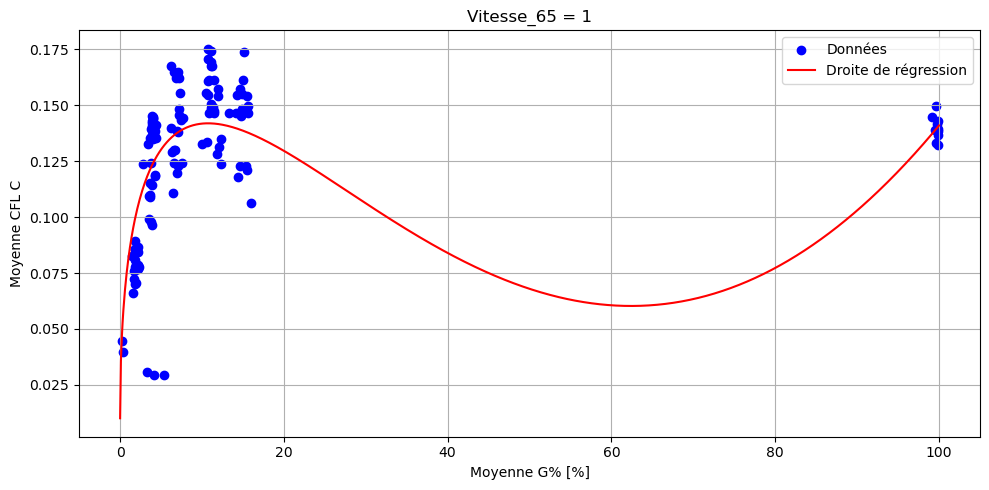

In [17]:
X = nfb.drop(["T° BDR (C)"], axis=1)
# X = scale_encode(X, 0)

x = np.linspace(0, 100, 1000)

plt.figure(figsize=(10, 5))

X_v = X.drop(['Moyenne CFL C'], axis=1)    
y_v = nfb['Moyenne CFL C']  # Notez le changement pour utiliser 'nfb'
    
    # Calculer les valeurs prédites
y_v_r = (a +
             b * x +
             c * x**2  +
             d * np.sqrt(x) )    
plt.scatter(X_v['Moyenne G% [%]'], y_v, color='blue', label='Données')
plt.plot(x, y_v_r, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Vitesse_65 = {1}')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [18]:
y_v_r[np.argmax(y_v_r)]

0.1419616492767471

### Attempt 2

Paramètres optimisés: [ 1.95808128e-02 -1.02386463e-02  4.35375441e-05  7.08242775e-02]
Erreur quadratique moyenne (entraînement): 0.023474047916062474
Erreur quadratique moyenne (test): 0.01471185884206524
La fonction est concave: False


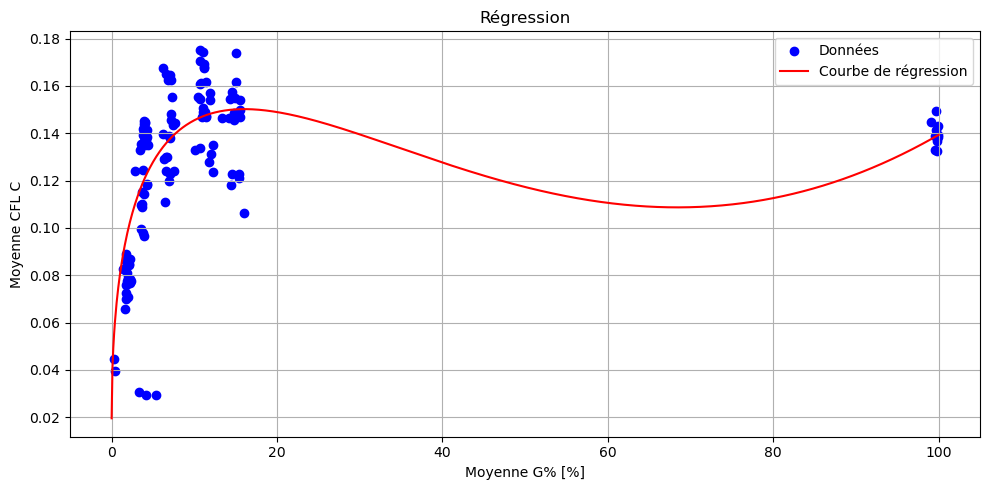

CPU times: total: 4.83 s
Wall time: 4.83 s


In [20]:
%%time

def objective(params, X, y):
    a, b, c, d = params
    y_pred = a + b * X['Moyenne G% [%]'] + c * X["g2"] + d * X["rg"]
    f = lambda x: a + b * x + c * x**2 + d * np.sqrt(x)
    
    x = np.linspace(0, 100, 1000)
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    
    max_abscissa_diff = abs(g_max_real  - g_max_pred) 
    
    mse = mean_squared_error(y, y_pred)
    g = X['Moyenne G% [%]'].max()
    cost = 15* 1/(data.shape[0])*abs(y-y_pred).sum() + 1000*abs(2*c - d/(4*g**(3/2))) + 0.008 * max_abscissa_diff
    return cost

def check_concavity(params):
    a, b, c, d = params
    x = np.linspace(X['Moyenne G% [%]'].min(), X['Moyenne G% [%]'].max(), 1000)
    second_derivative = 2*c - d/(4*x**(3/2))
    return np.all(second_derivative < 0)

# Préparation des données
data = nfb 
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
X["rg"] = np.sqrt(X['Moyenne G% [%]'])
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']
st = X['Moyenne G% [%]'].apply(descritisation_nfb)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=st, random_state=13)

# Définir les bornes des paramètres
bounds = [(0.01, 0.02), (-0.5, 0.5), (-0.5, 0.5), (-0.5, 0.5)]

# Optimisation globale avec differential_evolution
result_de = differential_evolution(objective, bounds, args=(X_train, y_train),  maxiter=1000, popsize=20)

# Utiliser le résultat de differential_evolution comme point de départ pour l'optimisation locale
result = minimize(objective, result_de.x, args=(X_train, y_train), 
                  method='SLSQP', bounds=bounds)

optimal_params = result.x
print("Paramètres optimisés:", optimal_params)

# Prédire avec les paramètres optimisés
a, b, c, d = optimal_params
y_pred_train = a + b * X_train['Moyenne G% [%]'] + c * X_train["g2"] + d * X_train["rg"]
y_pred_test = a + b * X_test['Moyenne G% [%]'] + c * X_test["g2"] + d * X_test["rg"]

# Calculer et afficher les erreurs quadratiques moyennes
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
print("Erreur quadratique moyenne (entraînement):", rmse_train)
print("Erreur quadratique moyenne (test):", rmse_test)

# Vérifier la concavité
is_concave = check_concavity(optimal_params)
print("La fonction est concave:", is_concave)

# Visualisation
X_v = nfb.drop(['Moyenne CFL C'], axis=1)
y_v = nfb['Moyenne CFL C']

x = np.linspace(0, 100, 1000)
y_v_r = a + b * x + c * x**2 + d * np.sqrt(x)

plt.figure(figsize=(10, 5))
plt.scatter(X_v['Moyenne G% [%]'], y_v, color='blue', label='Données')
plt.plot(x, y_v_r, color='red', label='Courbe de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Régression')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


## Attempt 3

Paramètres optimisés: [ 1.00729579e-02 -1.57921397e-02  1.19412573e-04  8.75461391e-02
 -3.61762467e-07]
Erreur quadratique moyenne (entraînement): 0.024309814337746333
Erreur quadratique moyenne (test): 0.09822768959788822
La fonction est concave: False


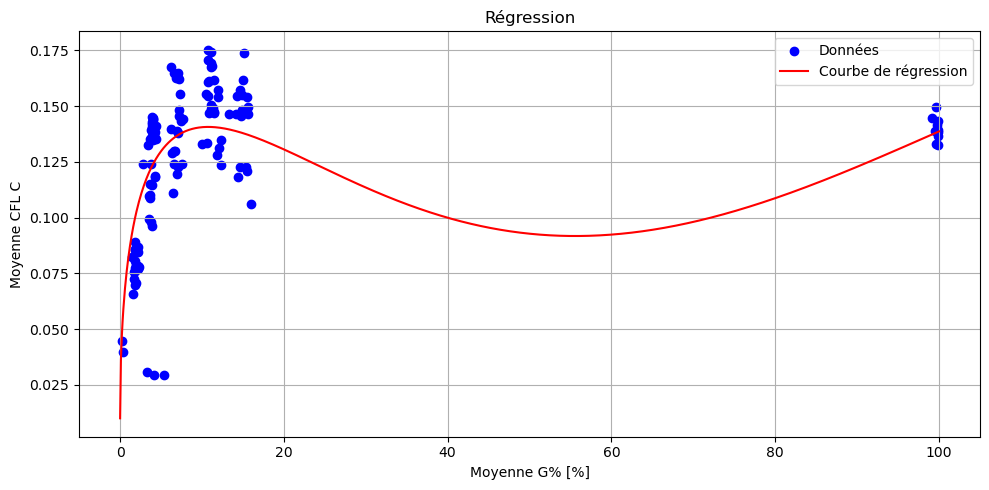

CPU times: total: 16.9 s
Wall time: 17 s


In [23]:
%%time

def objective(params, X, y):
    a, b, c, d, e = params
    y_pred = a + b * X['Moyenne G% [%]'] + c * X["g2"] + d * X["rg"] + e * X["g3"]
    f = lambda x: a + b * x + c * x**2 + d * np.sqrt(x) + e*x**3
    
    x = np.linspace(0, 100, 1000)
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    
    max_abscissa_diff = abs(g_max_real + - g_max_pred) 
    
    mse = mean_squared_error(y, y_pred)
    g = X['Moyenne G% [%]'].max()
    cost = 15*mse + 1000*abs(2*c - d/(4*g**(3/2))   + 6*e*g) + 0.007 * max_abscissa_diff
    return cost

def check_concavity(params):
    a, b, c, d, e = params
    x = np.linspace(X['Moyenne G% [%]'].min(), X['Moyenne G% [%]'].max(), 1000)
    second_derivative = 2*c - d/(4*x**(3/2) + 6*e*x)
    return np.all(second_derivative < 0)

# Préparation des données
data = nfb 
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
X["rg"] = np.sqrt(X['Moyenne G% [%]'])
X["g2"] = X['Moyenne G% [%]']**2
X["g3"] = X['Moyenne G% [%]']**3

y = data['Moyenne CFL C']
st = X['Moyenne G% [%]'].apply(descritisation_nfb)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=st, random_state=13)

# Définir les bornes des paramètres
bounds = [(0.01, 0.02), (-0.5, 0.5), (-0.5, 0.5), (-0.5, 0.5), (-10, 10)]

# Optimisation globale avec differential_evolution
result_de = differential_evolution(objective, bounds, args=(X_train, y_train),  maxiter=1000, popsize=20)

# Utiliser le résultat de differential_evolution comme point de départ pour l'optimisation locale
result = minimize(objective, result_de.x, args=(X_train, y_train), 
                  method='SLSQP', bounds=bounds)

optimal_params = result.x
print("Paramètres optimisés:", optimal_params)

# Prédire avec les paramètres optimisés
a, b, c, d, e = optimal_params
y_pred_train = a + b * X_train['Moyenne G% [%]'] + c * X_train["g2"] + d * X_train["rg"] + e*X_train["g3"]
y_pred_test = a + b * X_test['Moyenne G% [%]'] + c * X_test["g2"] + d * X_test["rg"] + e*X_test["g2"]

# Calculer et afficher les erreurs quadratiques moyennes
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
print("Erreur quadratique moyenne (entraînement):", rmse_train)
print("Erreur quadratique moyenne (test):", rmse_test)

# Vérifier la concavité
is_concave = check_concavity(optimal_params)
print("La fonction est concave:", is_concave)

# Visualisation
X_v = nfb.drop(['Moyenne CFL C'], axis=1)
y_v = nfb['Moyenne CFL C']

x = np.linspace(0, 100, 1000)
y_v_r = a + b * x + c * x**2 + d * np.sqrt(x) +e*x**3

plt.figure(figsize=(10, 5))
plt.scatter(X_v['Moyenne G% [%]'], y_v, color='blue', label='Données')
plt.plot(x, y_v_r, color='red', label='Courbe de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Régression')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


## Neige fraiche (G) (129 observations)

### Ajout de coeft deg >1

In [239]:
def descritisation_nfg(x):
    if x<3:
        return "3"
    elif x< 6:
        return "6"
    elif x< 9:
        return "9"
    elif x< 13:
        return "13"
    elif x< 16:
        return "16"
    else:
        return "more"

In [240]:
X = nfg.drop(['Moyenne CFL C',"T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_nfg)

X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)


X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']




y= nfg['Moyenne CFL C']

stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = stratify_combined, random_state=2)
regressor = LinearRegression()
regressor.fit(X_train, y_train)
        
        
display(coef(1))
intercept = float(coef()[coef().Feature == "Intercept"].Coefficient)
coefficients = {
    'Moyenne G% [%]': float(coef()[coef().Feature == 'Moyenne G% [%]'].Coefficient),
    'log(g)':float(coef()[coef().Feature == 'log(g)'].Coefficient),
    'Vitesse_65': float(coef()[coef().Feature == 'Vitesse_65'].Coefficient),
    'g2': float(coef()[coef().Feature == 'g2'].Coefficient),
    'g*V':float(coef()[coef().Feature == 'g*V'].Coefficient)
}

Pour le test: RMSE = 0.01647, R² = 84.46, MAE = 0.01296
Pour le train: RMSE = 0.01186, R² = 89.23, MAE = 0.00934


,Feature,Coefficient
0,Intercept,0.063436
1,Moyenne G% [%],-0.003297
2,log(g),0.057988
3,Vitesse_65,-0.017965
4,g2,0.000012
5,g*V,0.000390


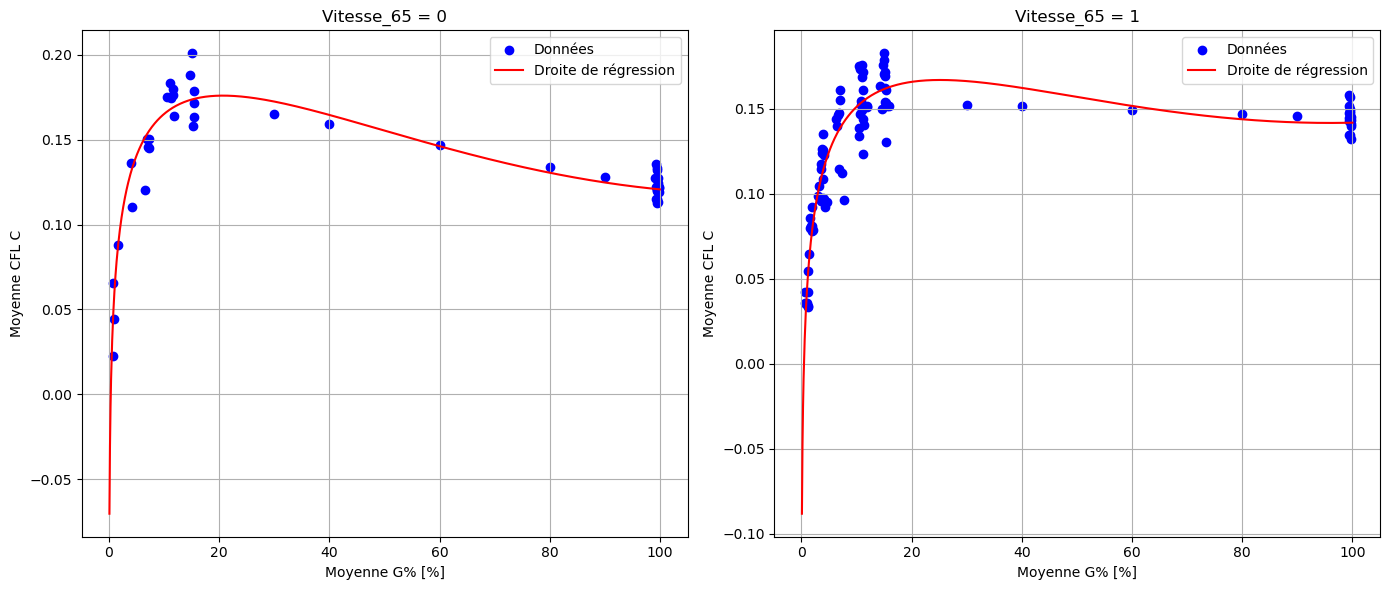

In [241]:
# Préparation des données
X = nfg.drop(["T° BDR (C)"], axis=1)
X = scale_encode(X, 0)



x = np.linspace(0, 100, 1000)
plt.figure(figsize=(14, 6))

for i in [0,1]:
    X_v = X[X['Vitesse_65'] == i].drop(['Moyenne CFL C'], axis=1)    
    y_v = X[X['Vitesse_65'] == i]['Moyenne CFL C']
    y_v_r = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * i +
                   coefficients['g2'] * x**2 +
                   coefficients['g*V'] * (x * i))
    plt.subplot(1, 2, i+1)
    plt.scatter(X_v['Moyenne G% [%]'], y_v, color='blue', label='Données')
    plt.plot(x, y_v_r, color='red', label='Droite de régression')
    plt.xlabel('Moyenne G% [%]')
    plt.ylabel('Moyenne CFL C')
    plt.title(f'Vitesse_65 = {i}')
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()


## N.C. (G) (111 observations)

### Ajout de coeft deg >1

In [244]:
def descritisation_ncg(x):
    if x<2:
        return "2"
    elif x< 5:
        return "5"
    elif x< 9:
        return "9"
    elif x< 12:
        return "12"
    elif x< 15:
        return "15"
    elif x< 17:
        return "17"
    else:
        return "more"

In [245]:
X = ncg.drop(['Moyenne CFL C',"T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_ncg)

X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)


X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']




y= ncg['Moyenne CFL C']

stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = stratify_combined, random_state=2)
regressor = LinearRegression()
regressor.fit(X_train, y_train)
        
        
display(coef(1))
intercept = float(coef()[coef().Feature == "Intercept"].Coefficient)
coefficients = {
    'Moyenne G% [%]': float(coef()[coef().Feature == 'Moyenne G% [%]'].Coefficient),
    'log(g)':float(coef()[coef().Feature == 'log(g)'].Coefficient),
    'Vitesse_65': float(coef()[coef().Feature == 'Vitesse_65'].Coefficient),
    'g2': float(coef()[coef().Feature == 'g2'].Coefficient),
    'g*V':float(coef()[coef().Feature == 'g*V'].Coefficient)
}

Pour le test: RMSE = 0.01951, R² = 86.94, MAE = 0.01604
Pour le train: RMSE = 0.0246, R² = 82.76, MAE = 0.01962


,Feature,Coefficient
0,Intercept,0.063342
1,Moyenne G% [%],-0.002796
2,log(g),0.070801
3,Vitesse_65,-0.030052
4,g2,0.000003
5,g*V,0.000684


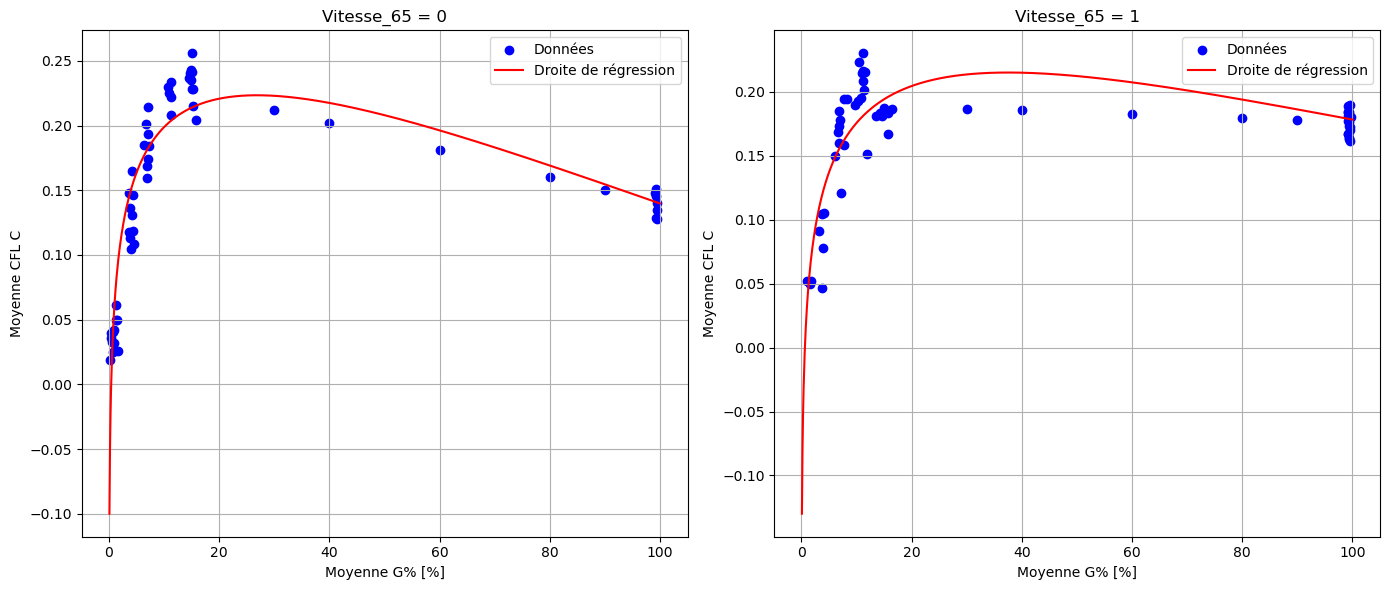

In [246]:
# Préparation des données
X = ncg.drop(["T° BDR (C)"], axis=1)
X = scale_encode(X, 0)



x = np.linspace(0, 100, 1000)
plt.figure(figsize=(14, 6))

for i in [0,1]:
    X_v = X[X['Vitesse_65'] == i].drop(['Moyenne CFL C'], axis=1)    
    y_v = X[X['Vitesse_65'] == i]['Moyenne CFL C']
    y_v_r = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * i +
                   coefficients['g2'] * x**2 +
                   coefficients['g*V'] * (x * i))
    plt.subplot(1, 2, i+1)
    plt.scatter(X_v['Moyenne G% [%]'], y_v, color='blue', label='Données')
    plt.plot(x, y_v_r, color='red', label='Droite de régression')
    plt.xlabel('Moyenne G% [%]')
    plt.ylabel('Moyenne CFL C')
    plt.title(f'Vitesse_65 = {i}')
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()


## N.C. (B) (141 observations)

### Ajout de coeft deg >1

In [247]:
def descritisation_ncb(x):
    if x<2:
        return "2"
    elif x< 6:
        return "6"
    elif x< 9:
        return "9"
    elif x< 13:
        return "13"
    elif x< 16:
        return "16"
    else:
        return "more"

In [248]:
X = ncb.drop(['Moyenne CFL C',"T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_ncb)

X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)


X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']




y= ncb['Moyenne CFL C']

stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = stratify_combined, random_state=2)
regressor = LinearRegression()
regressor.fit(X_train, y_train)
        
        
display(coef(1))
intercept = float(coef()[coef().Feature == "Intercept"].Coefficient)
coefficients = {
    'Moyenne G% [%]': float(coef()[coef().Feature == 'Moyenne G% [%]'].Coefficient),
    'log(g)':float(coef()[coef().Feature == 'log(g)'].Coefficient),
    'Vitesse_65': float(coef()[coef().Feature == 'Vitesse_65'].Coefficient),
    'g2': float(coef()[coef().Feature == 'g2'].Coefficient),
    'g*V':float(coef()[coef().Feature == 'g*V'].Coefficient)
}

Pour le test: RMSE = 0.02351, R² = 79.49, MAE = 0.01891
Pour le train: RMSE = 0.02083, R² = 85.14, MAE = 0.01648


,Feature,Coefficient
0,Intercept,0.059548
1,Moyenne G% [%],-0.003098
2,log(g),0.074415
3,Vitesse_65,-0.009162
4,g2,0.000005
5,g*V,0.000349


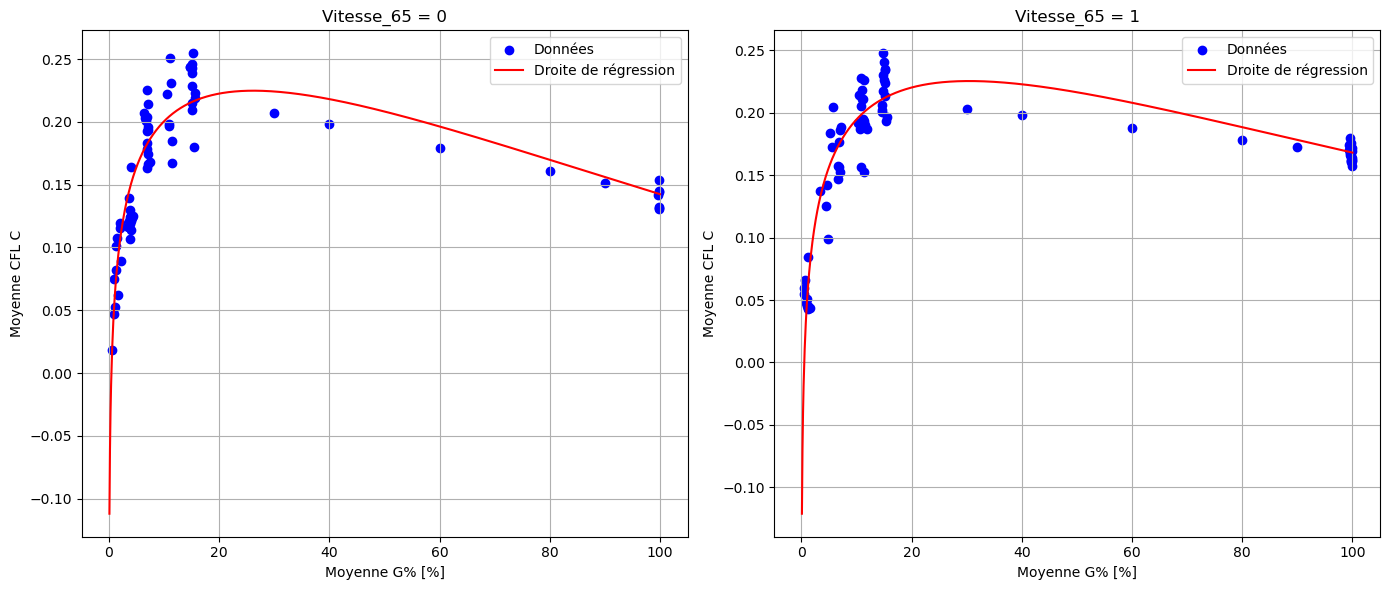

In [249]:
# Préparation des données
X = ncb.drop(["T° BDR (C)"], axis=1)
X = scale_encode(X, 0)



x = np.linspace(0, 100, 1000)
plt.figure(figsize=(14, 6))

for i in [0,1]:
    X_v = X[X['Vitesse_65'] == i].drop(['Moyenne CFL C'], axis=1)    
    y_v = X[X['Vitesse_65'] == i]['Moyenne CFL C']
    y_v_r = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * i +
                   coefficients['g2'] * x**2 +
                   coefficients['g*V'] * (x * i))
    plt.subplot(1, 2, i+1)
    plt.scatter(X_v['Moyenne G% [%]'], y_v, color='blue', label='Données')
    plt.plot(x, y_v_r, color='red', label='Droite de régression')
    plt.xlabel('Moyenne G% [%]')
    plt.ylabel('Moyenne CFL C')
    plt.title(f'Vitesse_65 = {i}')
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()


## NC.C. (238 observations)

### Ajout de coeft deg >1

In [250]:
def descritisation_ncc(x):
    if x<2:
        return "2"
    if x<4:
        return "4"
    if x<6:
        return "6"
    elif x< 8:
        return "8"
    elif x< 11:
        return "11"
    elif x< 14:
        return "14"
    elif x< 16:
        return "16"
    else:
        return "more"

In [251]:
X = ncc.drop(['Moyenne CFL C',"T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_ncc)

X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)


X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']




y= ncc['Moyenne CFL C']

stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = stratify_combined, random_state=2)
regressor = LinearRegression()
regressor.fit(X_train, y_train)
        
        
display(coef(1))
intercept = float(coef()[coef().Feature == "Intercept"].Coefficient)
coefficients = {
    'Moyenne G% [%]': float(coef()[coef().Feature == 'Moyenne G% [%]'].Coefficient),
    'log(g)':float(coef()[coef().Feature == 'log(g)'].Coefficient),
    'Vitesse_65': float(coef()[coef().Feature == 'Vitesse_65'].Coefficient),
    'g2': float(coef()[coef().Feature == 'g2'].Coefficient),
    'g*V':float(coef()[coef().Feature == 'g*V'].Coefficient)
}

Pour le test: RMSE = 0.0213, R² = 84.01, MAE = 0.01598
Pour le train: RMSE = 0.02028, R² = 85.07, MAE = 0.01475


,Feature,Coefficient
0,Intercept,0.101139
1,Moyenne G% [%],-0.005815
2,log(g),0.086025
3,Vitesse_65,-0.024134
4,g2,0.000024
5,g*V,0.000504


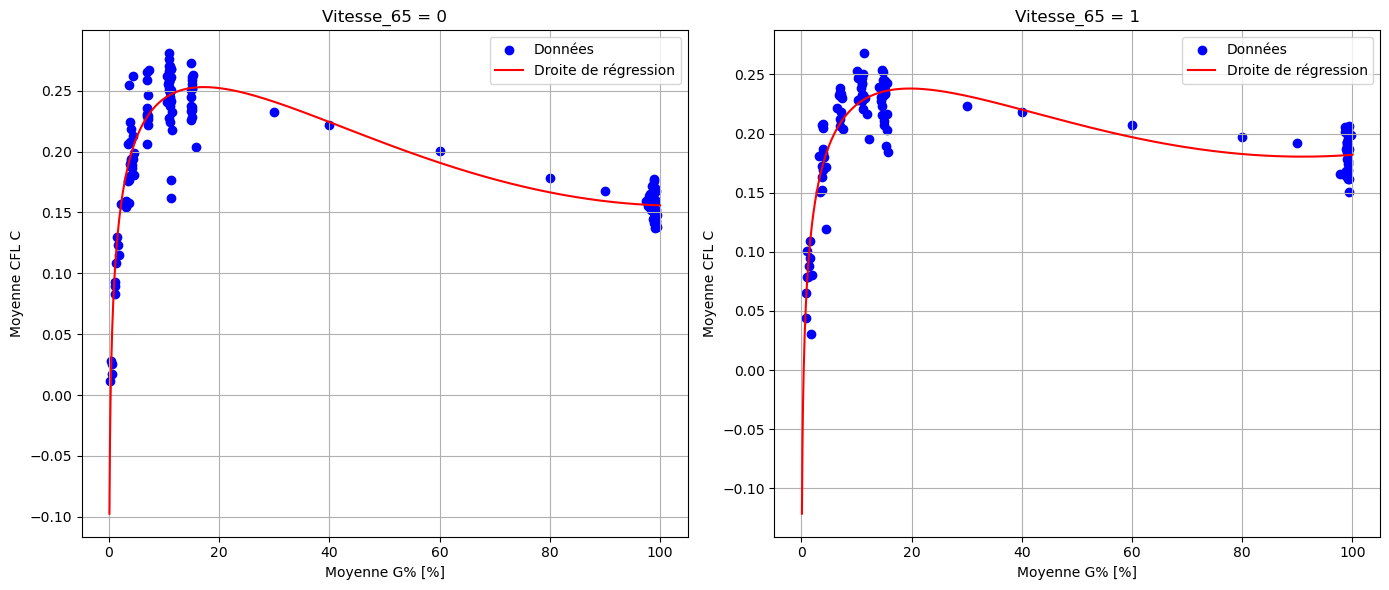

In [252]:
# Préparation des données
X = ncc.drop(["T° BDR (C)"], axis=1)
X = scale_encode(X, 0)



x = np.linspace(0, 100, 1000)
plt.figure(figsize=(14, 6))

for i in [0,1]:
    X_v = X[X['Vitesse_65'] == i].drop(['Moyenne CFL C'], axis=1)    
    y_v = X[X['Vitesse_65'] == i]['Moyenne CFL C']
    y_v_r = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * i +
                   coefficients['g2'] * x**2 +
                   coefficients['g*V'] * (x * i))
    plt.subplot(1, 2, i+1)
    plt.scatter(X_v['Moyenne G% [%]'], y_v, color='blue', label='Données')
    plt.plot(x, y_v_r, color='red', label='Droite de régression')
    plt.xlabel('Moyenne G% [%]')
    plt.ylabel('Moyenne CFL C')
    plt.title(f'Vitesse_65 = {i}')
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()


## Verglas (60 observations) ..


### Ajout de coeft deg >1

In [253]:
def descritisation_verglas(x):
    if x<2:
        return "2"
    if x<5:
        return "5"
    if x<11:
        return "11"
    elif x< 13:
        return "13"
    elif x< 17:
        return "17"
    else:
        return "more"

In [254]:
X = ver.drop(['Moyenne CFL C',"T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_verglas)

X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)


X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']




y= ver['Moyenne CFL C']

stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = stratify_combined, random_state=2)
regressor = LinearRegression()
regressor.fit(X_train, y_train)
        
        
display(coef(1))
intercept = float(coef()[coef().Feature == "Intercept"].Coefficient)
coefficients = {
    'Moyenne G% [%]': float(coef()[coef().Feature == 'Moyenne G% [%]'].Coefficient),
    'log(g)':float(coef()[coef().Feature == 'log(g)'].Coefficient),
    'Vitesse_65': float(coef()[coef().Feature == 'Vitesse_65'].Coefficient),
    'g2': float(coef()[coef().Feature == 'g2'].Coefficient),
    'g*V':float(coef()[coef().Feature == 'g*V'].Coefficient)
}

Pour le test: RMSE = 0.02044, R² = 67.7, MAE = 0.0166
Pour le train: RMSE = 0.01704, R² = 77.83, MAE = 0.01364


,Feature,Coefficient
0,Intercept,0.048408
1,Moyenne G% [%],-0.003693
2,log(g),0.053307
3,Vitesse_65,0.012040
4,g2,0.000021
5,g*V,-0.000215


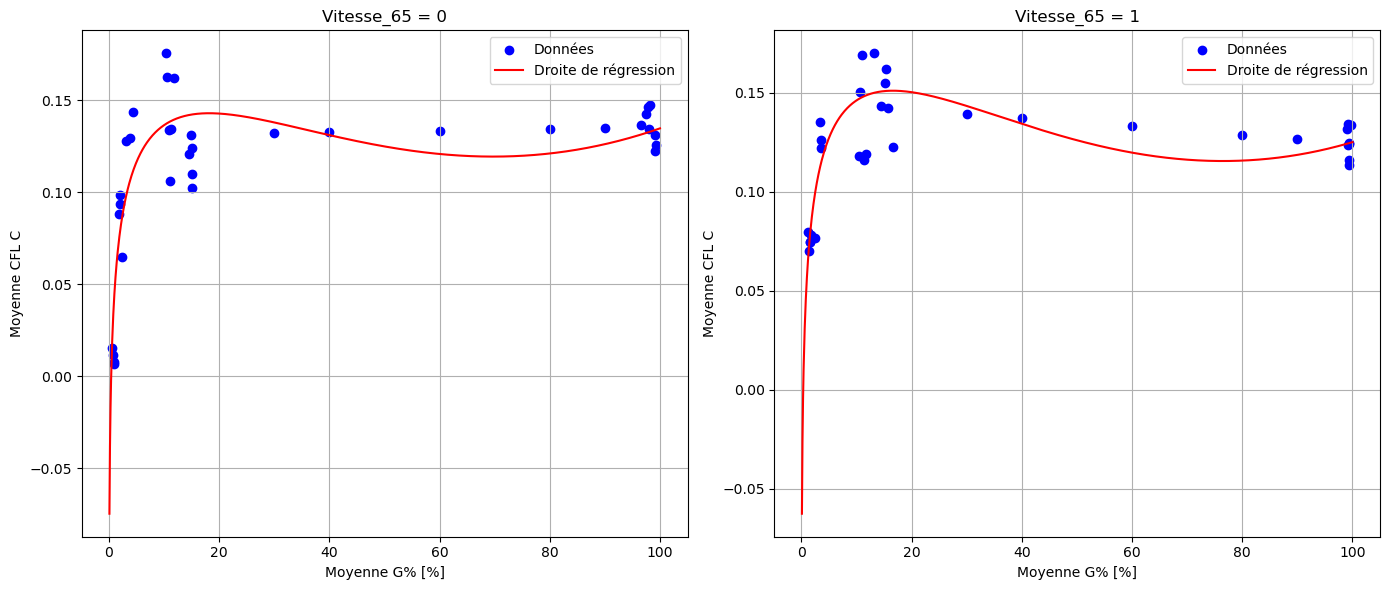

In [255]:
# Préparation des données
X = ver.drop(["T° BDR (C)"], axis=1)
X = scale_encode(X, 0)



x = np.linspace(0, 100, 1000)
plt.figure(figsize=(14, 6))

for i in [0,1]:
    X_v = X[X['Vitesse_65'] == i].drop(['Moyenne CFL C'], axis=1)    
    y_v = X[X['Vitesse_65'] == i]['Moyenne CFL C']
    y_v_r = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * i +
                   coefficients['g2'] * x**2 +
                   coefficients['g*V'] * (x * i))
    plt.subplot(1, 2, i+1)
    plt.scatter(X_v['Moyenne G% [%]'], y_v, color='blue', label='Données')
    plt.plot(x, y_v_r, color='red', label='Droite de régression')
    plt.xlabel('Moyenne G% [%]')
    plt.ylabel('Moyenne CFL C')
    plt.title(f'Vitesse_65 = {i}')
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()


## Glace (122 observations)

Ici contrairement aux précedent contaminant, on a une variabilité significative de la température de bande de roulement.

### Ajout de coeft deg >1

In [256]:
def descritisation_glace(x):
    if x<3:
        return "3"
    if x<4:
        return "4"
    if x<6:
        return "6"
    if x<8:
        return "8"
    if x<11:
        return "11"
    elif x< 13:
        return "13"
    elif x< 15:
        return "15"
    elif x< 17:
        return "17"
    else:
        return "more"

In [257]:
X = gla.drop(['Moyenne CFL C',"T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_glace)


X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)


X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']




y= gla['Moyenne CFL C']

stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = stratify_combined, random_state=2)
regressor = LinearRegression()
regressor.fit(X_train, y_train)
        
        
display(coef(1))
intercept = float(coef()[coef().Feature == "Intercept"].Coefficient)
coefficients = {
    'Moyenne G% [%]': float(coef()[coef().Feature == 'Moyenne G% [%]'].Coefficient),
    'log(g)':float(coef()[coef().Feature == 'log(g)'].Coefficient),
    'Vitesse_65': float(coef()[coef().Feature == 'Vitesse_65'].Coefficient),
    'g2': float(coef()[coef().Feature == 'g2'].Coefficient),
    'g*V':float(coef()[coef().Feature == 'g*V'].Coefficient)
}


Pour le test: RMSE = 0.01373, R² = 84.13, MAE = 0.01094
Pour le train: RMSE = 0.01609, R² = 78.11, MAE = 0.01244


,Feature,Coefficient
0,Intercept,-0.054011
1,Moyenne G% [%],-0.002692
2,log(g),0.064458
3,Vitesse_65,0.017167
4,g2,0.000009
5,g*V,-0.000205


In [217]:
X.columns

Index(['Moyenne G% [%]', 'log(g)', 'Vitesse_65', 'g2', 'g*V'], dtype='object')

#### Remarque T° BDR (C) (normalisation ameliore le modele) !!!!!!!!!!!!!!!!!

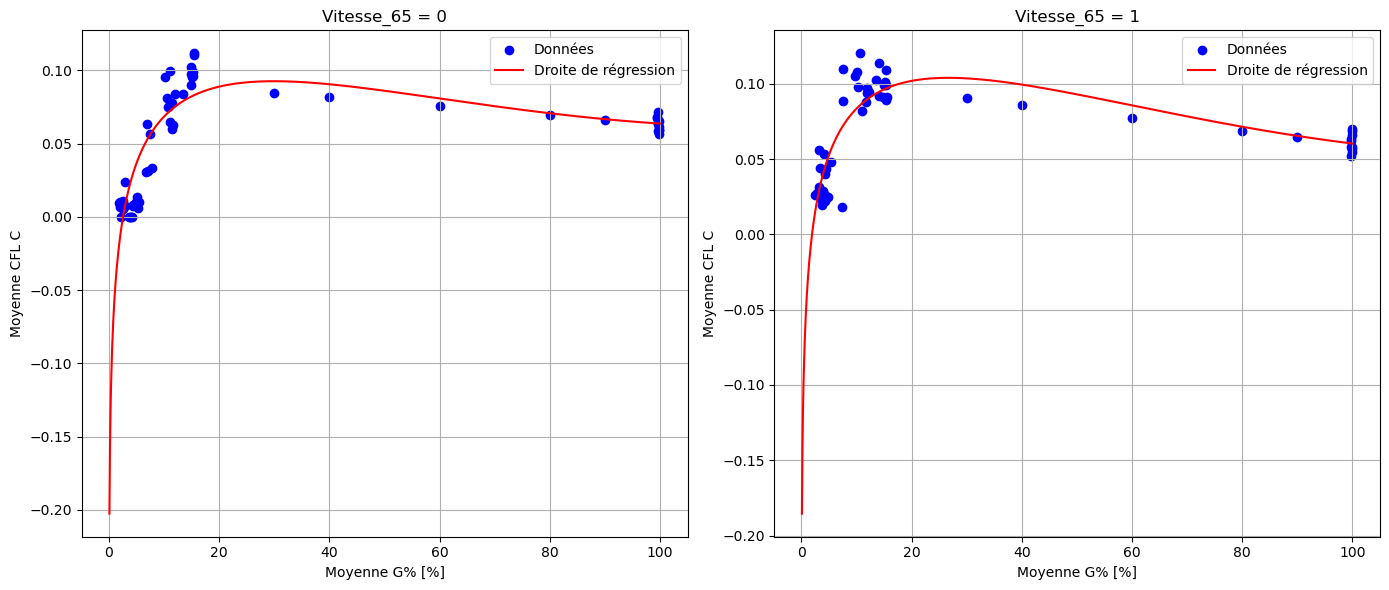

In [258]:
# Préparation des données
X = gla.drop(["T° BDR (C)"], axis=1)
X = scale_encode(X, 0)



x = np.linspace(0, 100, 1000)
plt.figure(figsize=(14, 6))

for i in [0,1]:
    X_v = X[X['Vitesse_65'] == i].drop(['Moyenne CFL C'], axis=1)    
    y_v = X[X['Vitesse_65'] == i]['Moyenne CFL C']
    y_v_r = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * i +
                   coefficients['g2'] * x**2 +
                   coefficients['g*V'] * (x * i))
    plt.subplot(1, 2, i+1)
    plt.scatter(X_v['Moyenne G% [%]'], y_v, color='blue', label='Données')
    plt.plot(x, y_v_r, color='red', label='Droite de régression')
    plt.xlabel('Moyenne G% [%]')
    plt.ylabel('Moyenne CFL C')
    plt.title(f'Vitesse_65 = {i}')
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()


## SLUSH (85 observations)

### Ajout de coeft deg >1

In [224]:
def descritisation_slh(x):
    if x<0.5:
        return "0.5"
    if x<1:
        return "1"
    if x<4:
        return "4"

    elif x< 14:
        return "14"
    else:
        return "more"


In [236]:
X = slh.drop(['Moyenne CFL C',"T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_slh)
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)

X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']


stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)

y= slh['Moyenne CFL C']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify = stratify_combined, random_state=68)#2 16   29   68
regressor = LinearRegression()
regressor.fit(X_train, y_train)

        
display(coef(1))
intercept = float(coef()[coef().Feature == "Intercept"].Coefficient)
coefficients = {
    'Moyenne G% [%]': float(coef()[coef().Feature == 'Moyenne G% [%]'].Coefficient),
    'log(g)':float(coef()[coef().Feature == 'log(g)'].Coefficient),
    'Vitesse_65': float(coef()[coef().Feature == 'Vitesse_65'].Coefficient),
    'g2': float(coef()[coef().Feature == 'g2'].Coefficient),
    'g*V':float(coef()[coef().Feature == 'g*V'].Coefficient)
}


Pour le test: RMSE = 0.02505, R² = 88.1, MAE = 0.0174
Pour le train: RMSE = 0.02359, R² = 88.59, MAE = 0.01811


,Feature,Coefficient
0,Intercept,0.042211
1,Moyenne G% [%],0.001471
2,log(g),0.019963
3,Vitesse_65,-0.019798
4,g2,-0.000010
5,g*V,-0.000441


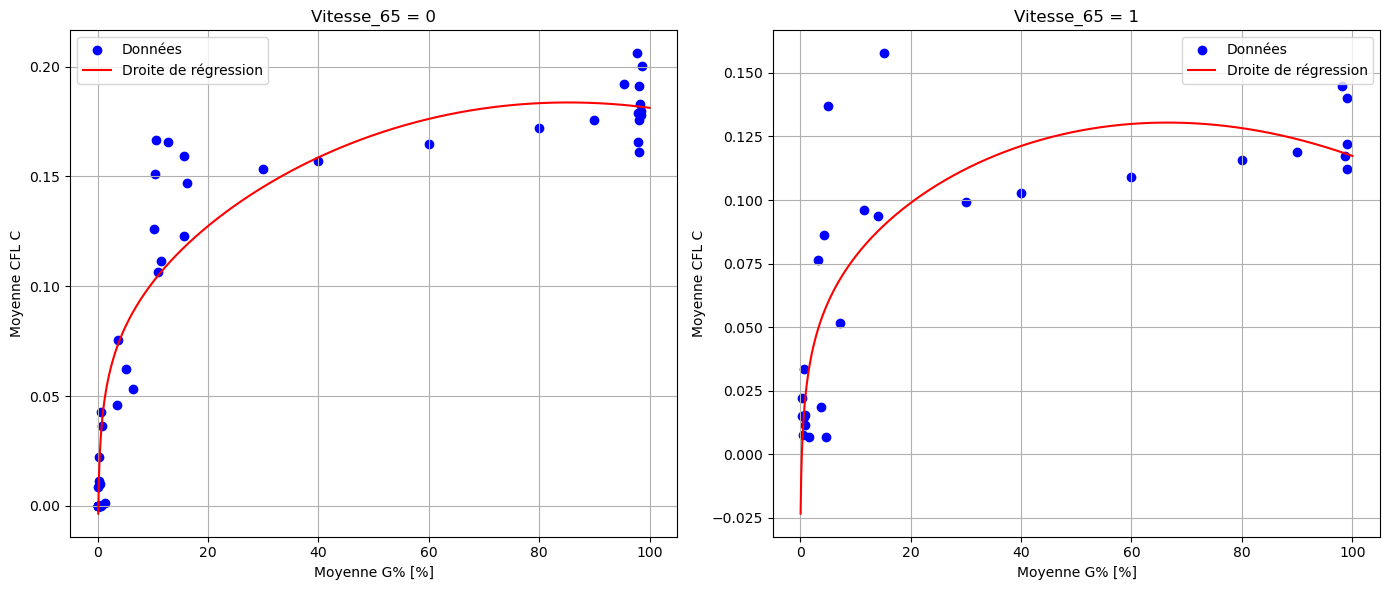

In [237]:
# Préparation des données
X = slh.drop(["T° BDR (C)"], axis=1)
X = scale_encode(X, 0)



x = np.linspace(0, 100, 1000)
plt.figure(figsize=(14, 6))

for i in [0,1]:
    X_v = X[X['Vitesse_65'] == i].drop(['Moyenne CFL C'], axis=1)    
    y_v = X[X['Vitesse_65'] == i]['Moyenne CFL C']
    y_v_r = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * i +
                   coefficients['g2'] * x**2 +
                   coefficients['g*V'] * (x * i))
    plt.subplot(1, 2, i+1)
    plt.scatter(X_v['Moyenne G% [%]'], y_v, color='blue', label='Données')
    plt.plot(x, y_v_r, color='red', label='Droite de régression')
    plt.xlabel('Moyenne G% [%]')
    plt.ylabel('Moyenne CFL C')
    plt.title(f'Vitesse_65 = {i}')
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()


# Fin modelisation lineaire

## Remarque

En raison de l'absence de données dans l'intervalle de 20 à 100 (aucune observation disponible dans cet intervalle), le modèle de régression fonctionne bien là où des données sont présentes, mais il produit des résultats erronés dans l'intervalle de 20 à 100. En réalité, il devrait montrer un plateau ou une courbe faiblement décroissante. Pour imposer ce plateau, nous allons créer des observations artificielles à trois positions (60, 80, 90) pour chaque contaminant et chaque vitesse. L'ajout de ces observations n'est pas aléatoire, étant donné que nous disposons d'observations au glissement 100 et que la courbe après 20 est faiblement décroissante. 

Les valeurs de CFL doivent être proches mais légèrement supérieures. Ainsi, pour le glissement 90, nous ajoutons la valeur médiane des CFL pour le glissement consigné 100 + 0,0025; pour 80, la valeur médiane des CFL pour le glissement consigné 100 + 0,005; et pour 60, la valeur médiane des CFL pour le glissement consigné 100 + 0,01.

Nous avons ajouté 48 observations à notre ensemble de données, ce qui représente 4,5% de la base de données initiale, afin de ne pas altérer la réalité du modèle tout en indiquant qu'il doit y avoir un plateau dans l'intervalle de 20 à 100. Le modèle a bien performé et compris la nécessité d'un plateau. Cependant, il produit un maximum après 20, alors que le maximum devrait se situer parmi nos observations (c'est-à-dire <20). 

Le maximum après 20 s'explique par :

- La tendance croissante des données entre 0 et 20, incitant le modèle à poursuivre cette croissance.
- L'absence de contrainte imposée sur le maximum, seulement sur le plateau.

